In [57]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# REQUIRED ARCHITECTURES FOR REFERENCE

## ORIGINAL CLIP ARCHITECTURE

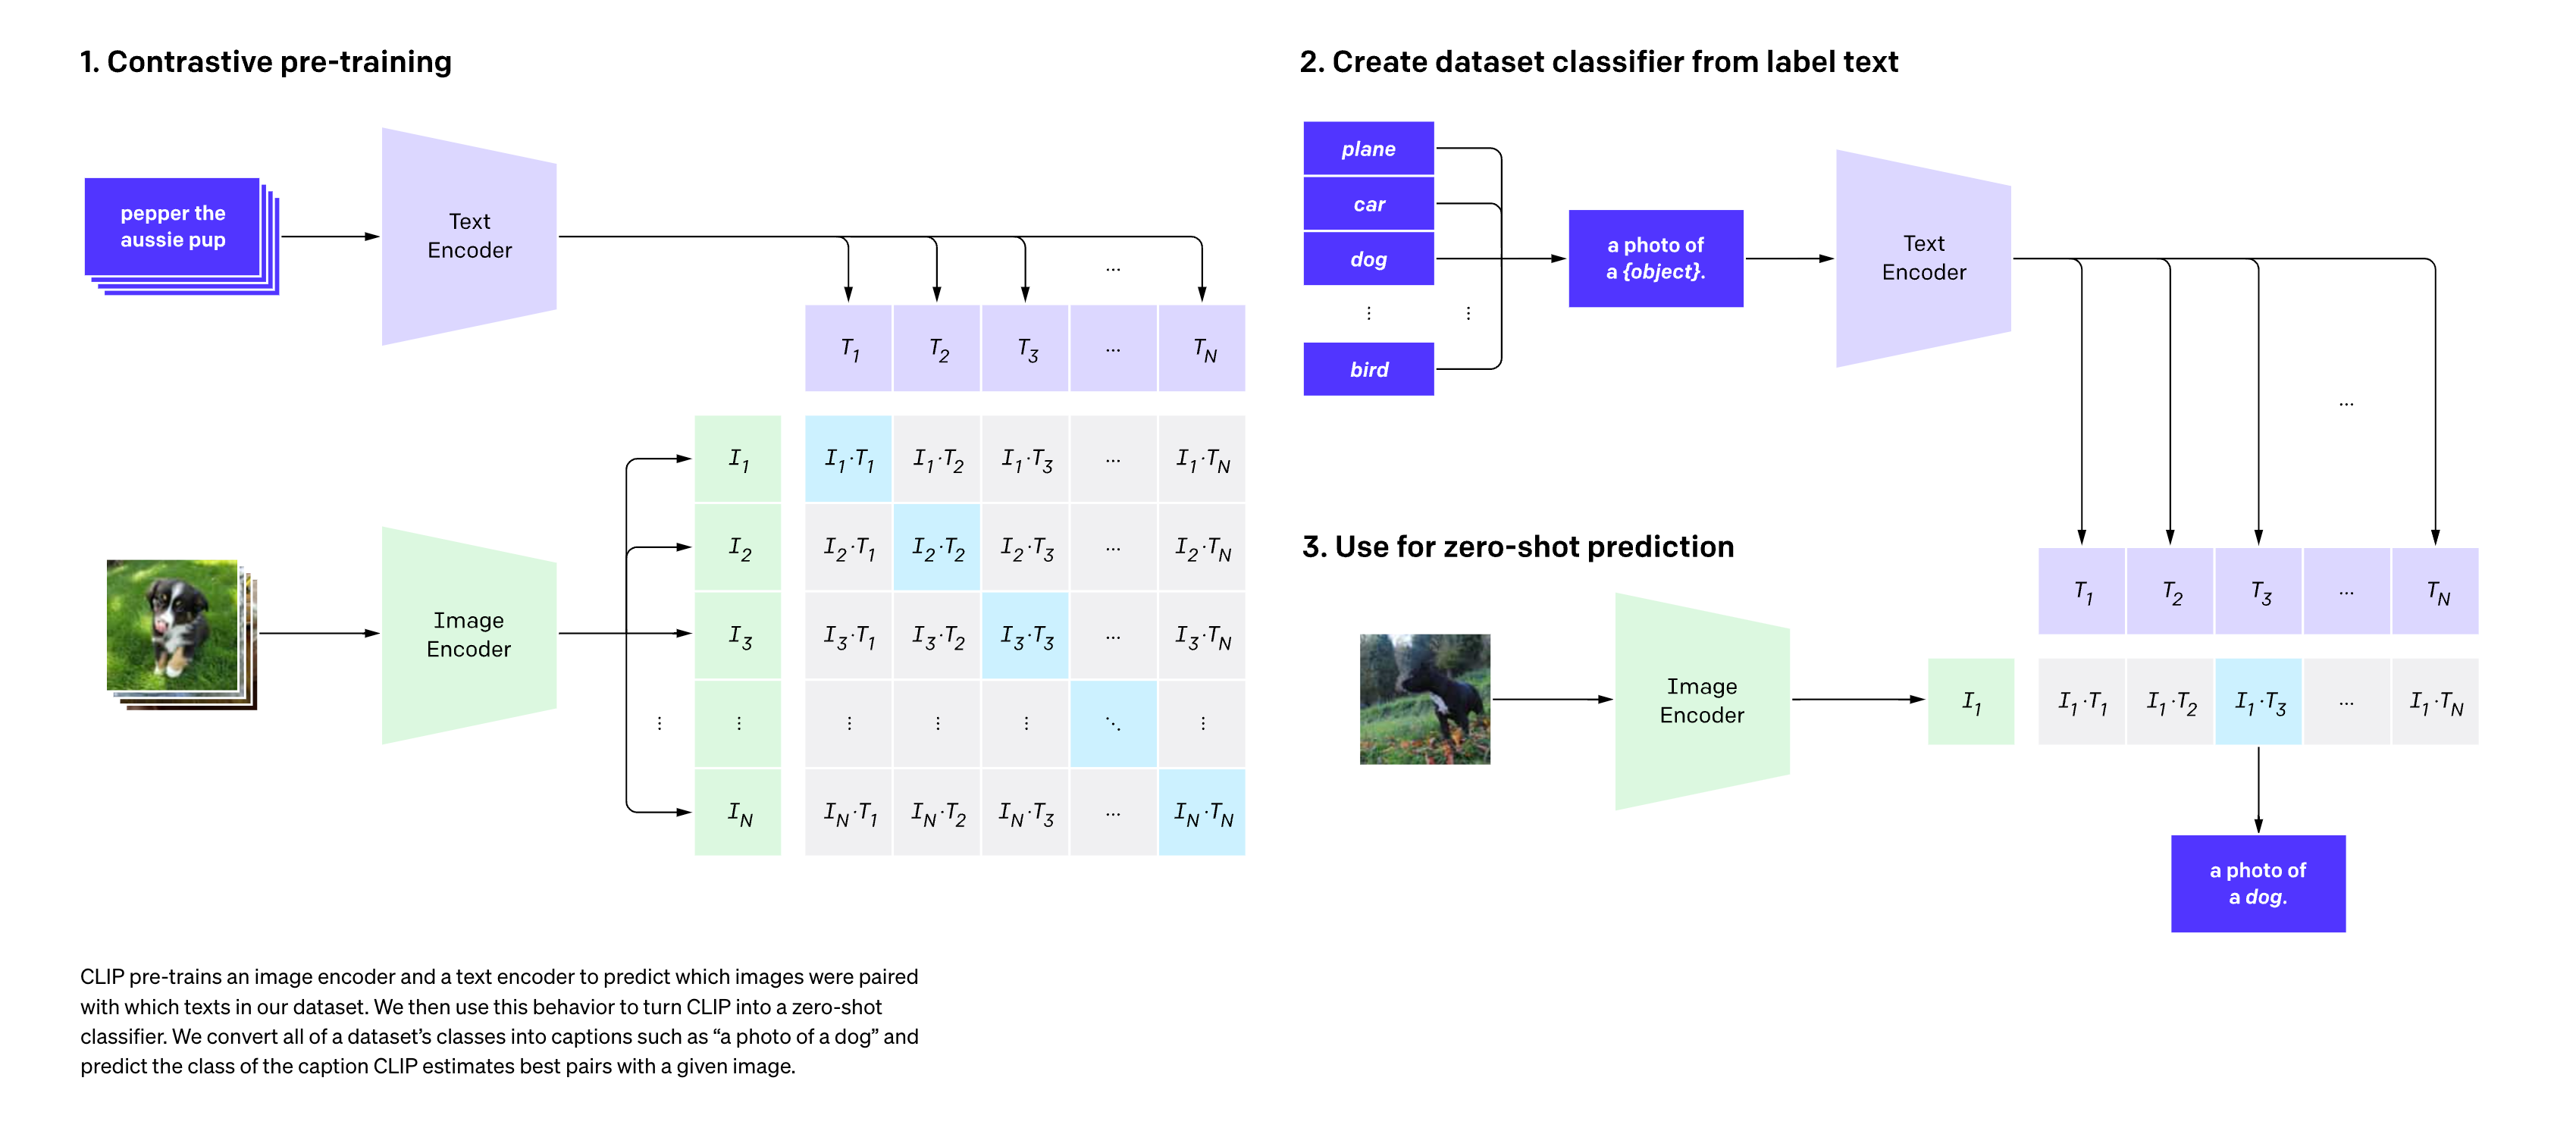

## VISION TRANSFORMER ARCHITECTURE

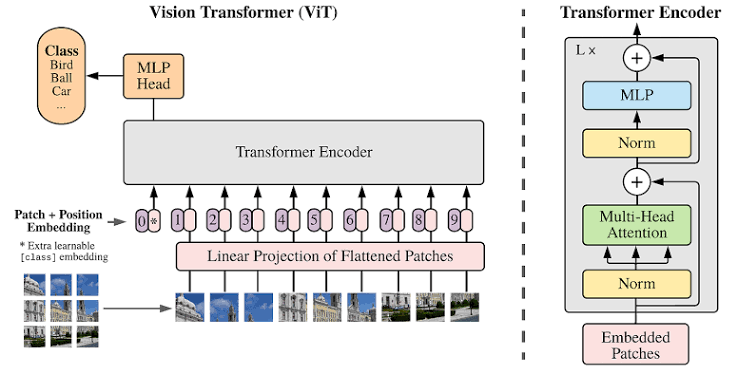

# IMPORTING REQUIRED MODULES AND LOADING THE DATASET

In [58]:
import torch
import csv
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets , transforms
from torch.utils.data import Dataset , DataLoader
from PIL import Image , ImageDraw
import matplotlib.pyplot as plt
import seaborn as sns
import tiktoken
import os

In [59]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
encoder = tiktoken.get_encoding("gpt2")

In [60]:
#MODEL CONFIGURATION
cfg = {"clip" : {
                    "temp" : 0.3 ,
                    "lr" : 1e-3 ,
                    "emb_dim" : 64 ,
                    "n_heads" : 1,
                    "n_layers" : 1,
                    "qkv_bias" : False,
                    "drop_rate" : 0.2
                } ,
       "img_encoder" : {
                          "patch_size" : 8 ,
                          "n_patches" : 784 , 
                          "input_channels" : 3
                       } ,
       "text_encoder" : {
                           "vocab_size" : 50257 ,
                           "context_window" : 77
                        }
      }

In [61]:
FLICKR_ROOT = "/content/drive/MyDrive/FLICKR-8K/IMAGES"
CAPTION_FILE = "/content/drive/MyDrive/FLICKR-8K/CAPTIONS/captions.txt"

preprocess = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

In [62]:
class Flickr8kDataset(Dataset):

    def __init__(self, root, caption_file, encoder, transform=None, context_window=77):
        self.root = root
        self.transform = transform
        self.context_window = context_window

        self.samples = []
        seen_images = set()

        with open(caption_file, newline="", encoding="utf-8") as f:
            reader = csv.reader(f)
            next(reader)

            for image_name, caption in reader:

                if image_name in seen_images:
                    continue

                if len(seen_images) >= 2000:
                    break

                seen_images.add(image_name)

                tokens = encoder.encode(caption)
                tokens = tokens[:context_window]

                if len(tokens) < context_window:
                    tokens += [encoder.eot_token] * (
                        context_window - len(tokens)
                    )

                tokens = torch.tensor(tokens, dtype=torch.long)

                self.samples.append((image_name, tokens))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        image_name, tokens = self.samples[idx]

        image_path = os.path.join(self.root, image_name)

        with Image.open(image_path) as img:
            image = img.convert("RGB")

        if self.transform is not None:
            image = self.transform(image)

        return image, tokens

In [63]:
dataset = Flickr8kDataset(
    root=FLICKR_ROOT,
    caption_file=CAPTION_FILE,
    encoder=encoder,
    transform=preprocess,
    context_window=cfg["text_encoder"]["context_window"]
)

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = torch.utils.data.random_split(
    dataset,
    [train_size, val_size]
)

train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True,
    prefetch_factor=4
)

val_loader = DataLoader(
    val_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True,
    prefetch_factor=4
)

print(len(train_dataset))
print(len(val_dataset))

1600
400


In [64]:
# Sanity check
img, label = next(iter(train_loader))
img.shape, label.shape

(torch.Size([16, 3, 224, 224]), torch.Size([16, 77]))

# MODEL CLASS

In [65]:
class CLIPModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.vit_encoder = VisionTransformerEncoder()
        self.text_encoder = TextEncoder()

    def forward(self, images, captions):
        img_emb = self.vit_encoder(images)
        txt_emb = self.text_encoder(captions)

        return img_emb, txt_emb

# COMMON CLASSES

In [66]:
class MultiHeadAttention (nn.Module) :
    def __init__(self , d_in , d_out , n_heads ,  qkv_bias) :
        super().__init__()
        assert (d_out % n_heads == 0) , "d_out must be divisible by n_heads"
        self.d_out = d_out
        self.n_heads = n_heads
        self.head_dim = self.d_out // self.n_heads
        self.qkv_bias = qkv_bias

        self.W_query = nn.Linear(d_in , self.d_out , bias = self.qkv_bias)
        self.W_key = nn.Linear(d_in , self.d_out , bias = self.qkv_bias)
        self.W_value = nn.Linear(d_in , self.d_out , bias = self.qkv_bias)

    def forward(self , x) :

        batch_size , n_patches , d_in = x.shape
        keys , queries , values = self.W_key(x) , self.W_query(x) , self.W_value(x)


        keys = keys.view(batch_size , n_patches , self.n_heads , self.head_dim).transpose(1,2)
        queries = queries.view(batch_size , n_patches , self.n_heads , self.head_dim).transpose(1,2)
        values = values.view(batch_size , n_patches , self.n_heads , self.head_dim).transpose(1,2)

        attn_scores = queries @ keys.transpose(2 , 3)
        attn_weights = torch.softmax(attn_scores / keys.shape[-1] ** 0.5 , dim = -1)

        context_vec = attn_weights @ values

        context_vec = context_vec.transpose(1,2)
        context_vec = context_vec.contiguous().view(batch_size , n_patches , self.d_out)

        return context_vec

In [67]:
class GeLU(nn.Module) :
    def __init__(self) :
        super().__init__()

    def forward(self , x) :
        return 0.5 * x * (1 + torch.tanh(
            torch.sqrt(torch.tensor(2.0 / torch.pi)) *
            (x + 0.044715 * torch.pow(x, 3))
        ))

In [68]:
class LayerNorm (nn.Module) :
    def __init__(self) :
        super().__init__()
        self.eps = 1e-5
        self.scale = nn.Parameter(torch.ones(cfg["clip"]["emb_dim"]))
        self.shift = nn.Parameter(torch.zeros(cfg["clip"]["emb_dim"]))
    def forward(self , x) :
        mean = torch.mean(x , dim = - 1 , keepdim = True)
        std = torch.std(x , dim = - 1 , keepdim = True)

        x = (x - mean) / std

        return self.scale * x + self.shift

# VISION TRANSFORMER ENCODER CLASS AND ITS COMPONENTS

In [69]:
class VisionTransformerEncoder(nn.Module) :
    def __init__ (self) :
        super().__init__()
        self.img_embedding = PatchEmbedding() #
        self.cls_token = nn.Parameter(torch.randn(1 , 1 , cfg["clip"]["emb_dim"]))
        self.pos_embedding = nn.Parameter(torch.randn(1 , cfg["img_encoder"]["n_patches"] + 1 , cfg["clip"]["emb_dim"]))
        self.trf_blocks = nn.Sequential(*[Transformer() for _ in range (cfg["clip"]["n_layers"])]) #
        self.linear = nn.Linear(cfg["clip"]["emb_dim"] , cfg["clip"]["emb_dim"])
        self.layer_norm = LayerNorm() #


    def forward(self , x) :
        b = x.size(0)
        x = self.img_embedding(x)
        class_token = self.cls_token.expand(b , - 1 , - 1)
        x = torch.cat([class_token , x] , dim = 1)
        x = x + self.pos_embedding
        x = self.trf_blocks(x)
        x = x[: , 0]
        x = F.normalize(self.layer_norm(x) , dim = - 1)
        return x


In [70]:
class PatchEmbedding(nn.Module) :
    def __init__(self) :
        super().__init__()
        self.conv = nn.Conv2d(cfg["img_encoder"]["input_channels"] ,
                              cfg["clip"]["emb_dim"] ,
                              kernel_size = cfg["img_encoder"]["patch_size"] ,
                              stride = cfg["img_encoder"]["patch_size"]
                             )
    def forward(self , x) :
        x = self.conv(x)
        x = x.flatten(2).transpose(1 , 2)
        return x

In [71]:
class EncoderMLP(nn.Module) :
    def __init__(self) :
        super().__init__()
        self.linear_1 = nn.Linear(cfg["clip"]["emb_dim"] , 4 * cfg["clip"]["emb_dim"])
        self.gelu = GeLU()
        self.linear_2 = nn.Linear(4 * cfg["clip"]["emb_dim"] , cfg["clip"]["emb_dim"])

    def forward(self , x) :

        x = self.linear_1(x)
        x=self.gelu(x)
        x=self.linear_2(x)

        return x

In [72]:
class Transformer(nn.Module) :
    def __init__(self) :
        super().__init__()
        self.pre_layer_norm_1 = LayerNorm()
        self.attention = MultiHeadAttention(d_in = cfg["clip"]["emb_dim"],
                                            d_out = cfg["clip"]["emb_dim"],
                                            n_heads = cfg["clip"]["n_heads"],
                                            qkv_bias = cfg["clip"]["qkv_bias"]
                                           )
        self.pre_layer_norm_2 = LayerNorm()
        self.mlp = EncoderMLP()
        self.dropout = nn.Dropout(p = cfg["clip"]["drop_rate"])

    def forward(self , x) :
        shortcut = x
        x = self.pre_layer_norm_1(x)
        x = self.attention(x)
        x = x + shortcut

        shortcut = x
        x = self.pre_layer_norm_2(x)
        x = self.mlp(x)
        x = self.dropout(x)
        x = x + shortcut
        return x

# TEXT ENCODER CLASS AND ITS COMPONENTS

In [73]:
class TextEncoder(nn.Module) :
  def __init__ (self , vocab_size = cfg["text_encoder"]["vocab_size"] , emb_dim = cfg["clip"]["emb_dim"] , n_heads = cfg["clip"]["n_heads"] , context_window = cfg["text_encoder"]["context_window"]) :
    super().__init__()
    self.token_embedding = nn.Embedding(vocab_size , emb_dim)
    self.position_embedding = nn.Embedding(context_window , emb_dim)
    self.attention = MultiHeadAttention(d_in = emb_dim,
                                        d_out = emb_dim,
                                        n_heads = n_heads,
                                        qkv_bias = cfg["clip"]["qkv_bias"]
                                        )
    self.projection = nn.Linear(emb_dim , emb_dim)
    self.dropout = nn.Dropout(p = cfg["clip"]["drop_rate"])
    self.norm = LayerNorm()

  def forward(self , x) :
    N , L = x.shape
    pos_ids = torch.arange(L , device = x.device).unsqueeze(0).expand(N , L)
    x = self.token_embedding(x) + self.position_embedding(pos_ids)
    x = self.attention(x)
    x = x[:,0]
    x = self.projection(x)
    x = self.dropout(x)
    x= F.normalize(self.norm(x) , dim = - 1)

    return x

# TRAINING AND EVALUATING MODEL

In [74]:
def clip_loss(img_emb, txt_emb, temperature=cfg["clip"]["temp"]):

    img_emb = F.normalize(img_emb, dim=-1)
    txt_emb = F.normalize(txt_emb, dim=-1)

    logits = img_emb @ txt_emb.T
    logits = logits / temperature

    targets = torch.arange(logits.size(0),device=logits.device)

    loss_i = F.cross_entropy(logits, targets)
    loss_t = F.cross_entropy(logits.T, targets)

    return (loss_i + loss_t) / 2

model = CLIPModel().to(device)

optimizer = torch.optim.AdamW(model.parameters(),lr=3e-4)

scaler = torch.amp.GradScaler("cuda")

epochs = 50

train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []

for epoch in range(epochs):
    model.train()

    train_loss = 0.0

    correct_img = 0
    correct_txt = 0
    total = 0

    for images, captions in train_loader:

        images = images.to(device, non_blocking=True)
        captions = captions.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast(device_type="cuda"):

            img_emb, txt_emb = model(images, captions)

            loss = clip_loss(img_emb, txt_emb)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        train_loss += loss.item()
        with torch.no_grad():

            img_emb = F.normalize(img_emb, dim=-1)
            txt_emb = F.normalize(txt_emb, dim=-1)

            sim = img_emb @ txt_emb.T

            targets = torch.arange(
                sim.size(0),
                device=device
            )

            pred_img = sim.argmax(dim=1)
            pred_txt = sim.argmax(dim=0)

            correct_img += (pred_img == targets).sum().item()
            correct_txt += (pred_txt == targets).sum().item()

            total += sim.size(0)

    avg_train_loss = train_loss / len(train_loader)

    train_acc = ((correct_img + correct_txt)/(2 * total)) * 100

    train_losses.append(avg_train_loss)
    train_accuracies.append(train_acc)
    model.eval()

    val_loss = 0.0

    correct_img = 0
    correct_txt = 0
    total = 0

    with torch.no_grad():

        for images, captions in val_loader:

            images = images.to(device, non_blocking=True)
            captions = captions.to(device, non_blocking=True)

            with torch.amp.autocast(device_type="cuda"):

                img_emb, txt_emb = model(images, captions)

                loss = clip_loss(img_emb, txt_emb)

            val_loss += loss.item()

            img_emb = F.normalize(img_emb, dim=-1)
            txt_emb = F.normalize(txt_emb, dim=-1)

            sim = img_emb @ txt_emb.T

            targets = torch.arange(
                sim.size(0),
                device=device
            )

            pred_img = sim.argmax(dim=1)
            pred_txt = sim.argmax(dim=0)

            correct_img += (pred_img == targets).sum().item()
            correct_txt += (pred_txt == targets).sum().item()

            total += sim.size(0)

    avg_val_loss = val_loss / len(val_loader)

    val_acc = ((correct_img + correct_txt)/(2 * total)) * 100

    val_losses.append(avg_val_loss)
    val_accuracies.append(val_acc)

    print(
        f"Epoch [{epoch+1}/{epochs}] | "
        f"Train Loss: {avg_train_loss:.4f} | "
        f"Train Acc: {train_acc:.2f}% | "
        f"Val Loss: {avg_val_loss:.4f} | "
        f"Val Acc: {val_acc:.2f}%"
    )

Epoch [1/50] | Train Loss: 2.7765 | Train Acc: 6.38% | Val Loss: 2.7727 | Val Acc: 6.12%
Epoch [2/50] | Train Loss: 2.7740 | Train Acc: 6.06% | Val Loss: 2.7726 | Val Acc: 6.62%
Epoch [3/50] | Train Loss: 2.7727 | Train Acc: 6.19% | Val Loss: 2.7726 | Val Acc: 6.88%
Epoch [4/50] | Train Loss: 2.7724 | Train Acc: 6.62% | Val Loss: 2.7725 | Val Acc: 6.62%
Epoch [5/50] | Train Loss: 2.7743 | Train Acc: 5.78% | Val Loss: 2.7725 | Val Acc: 6.25%
Epoch [6/50] | Train Loss: 2.7727 | Train Acc: 6.97% | Val Loss: 2.7726 | Val Acc: 6.88%
Epoch [7/50] | Train Loss: 2.7731 | Train Acc: 6.22% | Val Loss: 2.7722 | Val Acc: 6.75%
Epoch [8/50] | Train Loss: 2.7659 | Train Acc: 7.12% | Val Loss: 2.7637 | Val Acc: 7.38%
Epoch [9/50] | Train Loss: 2.7525 | Train Acc: 8.72% | Val Loss: 2.7571 | Val Acc: 7.00%
Epoch [10/50] | Train Loss: 2.7336 | Train Acc: 9.28% | Val Loss: 2.7456 | Val Acc: 8.38%
Epoch [11/50] | Train Loss: 2.6976 | Train Acc: 10.84% | Val Loss: 2.7241 | Val Acc: 8.88%
Epoch [12/50] | Tr

In [75]:
SAVE_PATH = "/content/drive/MyDrive/model_weights_clip.pth"
torch.save(
            {
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict()
            },
    SAVE_PATH
          )

LOAD_PATH = SAVE_PATH
checkpoint = torch.load(LOAD_PATH,map_location=device)

test_model = CLIPModel().to(device)
test_model.load_state_dict(checkpoint["model_state_dict"])

optimizer = torch.optim.AdamW(test_model.parameters(),lr=3e-4)

optimizer.load_state_dict(checkpoint["optimizer_state_dict"])

print("Loaded successfully!")

Loaded successfully!


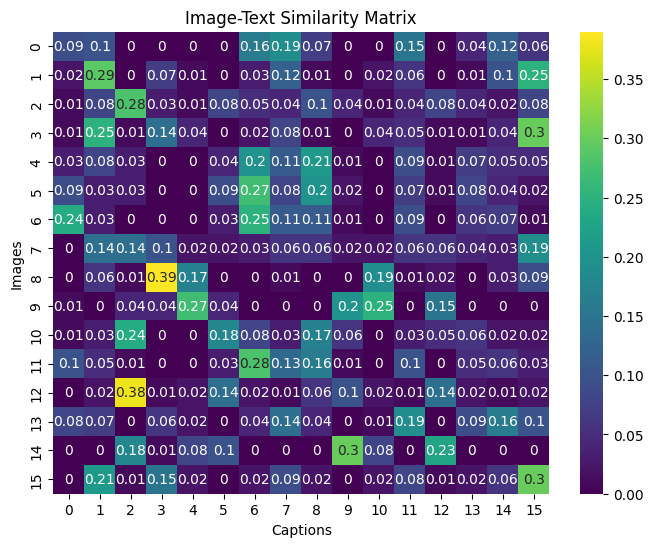

In [78]:
#Model Interpretation

model.eval()
images, tokens = next(iter(val_loader))
images = images.to(device)
tokens = tokens.to(device)
with torch.no_grad():
    img_emb = model.vit_encoder(images)
    txt_emb = model.text_encoder(tokens)

similarity = np.round((torch.softmax(img_emb@txt_emb.T/cfg["clip"]["temp"] , dim = 1)).cpu().numpy() , 2)
plt.figure(figsize=(8,6))

sns.heatmap(similarity,annot=True,cmap="viridis")
plt.xlabel("Captions")
plt.ylabel("Images")
plt.title("Image-Text Similarity Matrix")

plt.show()